In [10]:
import time
import import_ipynb
import numpy as np
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import import_ipynb
from datasets import TurtleSegmentationDataset
from pre_datas import image_portion
from model_trainer_evulate import ModelTrainer

In [11]:
def create_dataloader(data_type, metadat_path, annotations_file, base_dir,split_column='split_open'):
    train_path, valid_path, test_path, train_annotations, valid_annotations, test_annotations = image_portion(
        metadat_path, annotations_file, split_column)

    if data_type == 'train':
        train_dataset = TurtleSegmentationDataset(train_path, train_annotations, base_dir,image_size=(256, 256))
        train_loader = DataLoader(train_dataset, batch_size=8, shuffle=False, num_workers=2)
        return train_loader
    elif data_type == 'valid':
        valid_dataset = TurtleSegmentationDataset(valid_path, valid_annotations, base_dir,image_size=(256, 256))
        valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False, num_workers=2)
        return valid_loader
    else:
        test_dataset = TurtleSegmentationDataset(test_path, test_annotations,base_dir, image_size=(256, 256))
        test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)
        return test_loader


In [12]:
def main(model_type, num_epochs=50):
    metadat_path = '/root/turtles-data/data/metadata_splits.csv'
    annotations_file = '/root/turtles-data/data/annotations.json'
    base_dir = '/root/turtles-data/data'

    train_loader = create_dataloader('train', metadat_path, annotations_file,base_dir)  
    val_loader = create_dataloader('valid', metadat_path, annotations_file,base_dir)  

    best_miou = 0
    total_loss = 0
    train_loss_history = []
    iou_results_list = []
    class_ids = [1, 2, 3]  # head=1, turtle=2, flippers=3
    # class_names = ["turtle", "flippers", "head"]
    class_names = ["head", "turtle", "flippers"]

    trainer = ModelTrainer(4, model_type)

    for epoch in range(num_epochs):
        start_time = time.time()
        # train
        train_loss = trainer.train_epoch(train_loader)

        # verify
        val_loss, val_miou,iou_results = trainer.evaluate(val_loader,class_ids)

        # update learning rate
        trainer.scheduler.step(val_loss)

        # save model
        if val_miou > best_miou:
            best_miou = val_miou
            trainer.save_model(f'best_model_{model_type}.pth')

        train_loss_history.append(train_loss)
        iou_results_list.append(iou_results)

        print(f'Epoch {epoch + 1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val mIOU: {val_miou:.4f}, Time: {time.time() - start_time:.2f}s')

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_loss_history,label = 'train loss history',marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Epochs')
    plt.grid(True)
    plt.savefig(f'{model_type}_loss.jpg')
    plt.show()

    test_loader = create_dataloader('test',metadat_path, annotations_file,base_dir)
    test_loss, test_miou,iou_results_partion = trainer.evaluate(test_loader,class_ids)

    for class_id, class_name in zip(class_ids, class_names):
        print(f"IoU for {class_name}: {iou_results_partion[class_id]:.3f}")
         # Calculate overall mIoU (mean of class-wise IoUs)
    overall_miou = np.mean(list(iou_results_partion.values()))
    print(f"Overall mean IoU (mIoU): {overall_miou:.3f}")

In [13]:
# for types in ['U_Net','deeplabv3']:
#         main(type)

Training set contains 5302 images and 23304 annotations.
Validation set contains 1118 images and 4935 annotations.
Test set contains 2306 images and 10175 annotations.
Total images in metadata: 8729
Training set contains 5302 images and 23304 annotations.
Validation set contains 1118 images and 4935 annotations.
Test set contains 2306 images and 10175 annotations.
Total images in metadata: 8729


/root/miniconda3/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [11:21<00:00, 262kB/s] 


Epoch 1/50
Train Loss: 0.2131
Val Loss: 0.1409, Val mIOU: 0.5678, Time: 352.68s
Epoch 2/50
Train Loss: 0.1324
Val Loss: 0.1014, Val mIOU: 0.6633, Time: 342.22s
Epoch 3/50
Train Loss: 0.1090
Val Loss: 0.0923, Val mIOU: 0.6943, Time: 340.39s
Epoch 4/50
Train Loss: 0.0941
Val Loss: 0.0789, Val mIOU: 0.7295, Time: 343.51s
Epoch 5/50
Train Loss: 0.0848
Val Loss: 0.0751, Val mIOU: 0.7380, Time: 343.23s
Epoch 6/50
Train Loss: 0.0701
Val Loss: 0.0666, Val mIOU: 0.7653, Time: 343.46s
Epoch 7/50
Train Loss: 0.0655
Val Loss: 0.0642, Val mIOU: 0.7738, Time: 345.31s
Epoch 8/50
Train Loss: 0.0569
Val Loss: 0.0635, Val mIOU: 0.7825, Time: 345.87s
Epoch 9/50
Train Loss: 0.0625
Val Loss: 0.0636, Val mIOU: 0.7724, Time: 339.31s
Epoch 10/50
Train Loss: 0.0484
Val Loss: 0.0578, Val mIOU: 0.7982, Time: 342.24s
Epoch 11/50
Train Loss: 0.0487
Val Loss: 0.0765, Val mIOU: 0.7374, Time: 345.56s
Epoch 12/50
Train Loss: 0.0572
Val Loss: 0.0677, Val mIOU: 0.7765, Time: 339.67s
Epoch 13/50
Train Loss: 0.0460
Val Lo

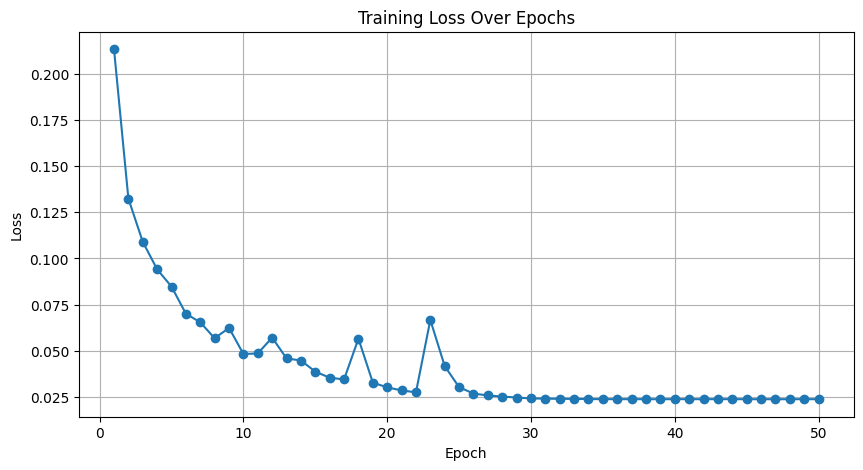

Training set contains 5302 images and 23304 annotations.
Validation set contains 1118 images and 4935 annotations.
Test set contains 2306 images and 10175 annotations.
Total images in metadata: 8729
IoU for head: 0.989
IoU for turtle: 0.935
IoU for flippers: 0.861
Overall mean IoU (mIoU): 0.928


In [14]:
main('deeplabv3')